# FDSI benchmark: 2. Hyperparameter search

The adaptation has three hyperparameters worth tuning: `wh_learning_rate` and
`sv_learning_rate` (how fast the whitening and the separation vectors follow the signal) and
`centroid_momentum` (how fast each unit's spike centroids do). `optimize_adapt_decomp` searches
them with Optuna on a **pool** of three recordings (subject 1, 30 dB, the 40, 10 and 5 s
triangular ramps), adapting each from the end of its calibration window. Five searches differ
in what they minimise:

| Search | Objective | Needs ground truth |
|---|---|---|
| `sv_mean`, `sv_sum` | `sv_loss`, the separation vectors' loss, averaged or summed over units | no |
| `pareto_mean`, `pareto_sum` | the Pareto front of `wh_loss` and `sv_loss`, taking its lowest-`sv_loss` member | no |
| `roa` | the RoA against the ground truth: the best a search could do | yes |

Each runs 100 trials, the first the `neuromotion` preset's values, then 14 random start-up
trials and 85 guided ones. The winner of each is applied to every recording in
[3. Apply](3_apply.ipynb).

In [1]:
import sys
from pathlib import Path

REPO_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "benchmarks" / "fdsi").is_dir()
)
sys.path.insert(0, str(REPO_ROOT))  # so that benchmarks.fdsi imports from any working directory

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display

from adapt_decomp import CBSSConfig, CBSSResult
from adapt_decomp.adaptation.optimize import optimize_adapt_decomp
from adapt_decomp.utils.loaders import PooledDatasetMemory
from adapt_decomp.utils.plots import (
    plot_search_front,
    plot_search_landscape,
    plot_search_parameters,
)
from benchmarks.fdsi import fdsi, pipeline, report

cfg = pipeline.load_config()
DATA_ROOT, CAL_END = pipeline.REPO_ROOT / cfg["data_root"], pipeline.cal_end(cfg)
pd.set_option("display.precision", 3)

## A short search

The pool, then a 3-trial `sv_mean` search on it: each trial adapts every pool recording from
the end of its calibration window with the suggested parameters and scores it. The pool's
calibrations come from [1. Calibration](1_calibrate.ipynb) (computed here if missing, about
2 min each). `n_cores` only sets the speed: by default the search uses every core available.

In [3]:
pool = {}
for rec in pipeline.pool_recordings(cfg):
    pipeline.calibrate_one(cfg, rec)  # skipped if done
    calibration = CBSSResult.load(pipeline.calibration_path(cfg, rec))
    emg = fdsi.load_raw_emg(DATA_ROOT, rec)
    gt = fdsi.load_gt_matched(DATA_ROOT, rec, calibration.gt_matched_indices, len(emg))
    pool[rec.cond] = PooledDatasetMemory(
        emg=torch.from_numpy(emg[CAL_END:].copy()),  # adapt from the end of the window
        calibration=calibration,
        cbss_config=CBSSConfig(**cfg["calibration"]["cbss_config"]),
        gt_paired_bin=gt[CAL_END:],  # for the RoA, reported next to the losses
    )

settings = pipeline.search_settings(cfg, "sv_mean")  # config.yaml's search section + sv_mean's
result = optimize_adapt_decomp(
    pool=pool,
    objectives=("sv_loss",),
    param_space=settings["param_space"],
    base_config=settings["base_config"],
    compute_roa=True,
    roa_kwargs={"tol_spike_ms": cfg["grid"]["tol_spike_ms"]},
    n_trials=3,
    random_seed=settings["random_seed"],
    initial_params=settings["initial_params"],
)
display(result.study.trials_dataframe().filter(regex="number|^value|params_|user_attrs_roa"))

2026-10-07 16:19:39.885 | INFO     | adapt_decomp.adaptation.optimize.resources:plan_search_resources:274 - 2 trial(s) at once x 3 worker(s) on 8 cores; predicted peak memory 11.4 GB of 860.2 GB free


[I 2026-10-07 16:19:39,887] A new study created in memory with name: no-name-db8250fb-ae56-4b92-937c-9f04c14e3fd7


2026-10-07 16:25:06.188 | INFO     | adapt_decomp.adaptation.optimize.workers:run_trials:194 - Trial 0 finished with values [22.787185668945312] and parameters {'wh_learning_rate': 0.007, 'sv_learning_rate': 0.003, 'centroid_momentum': 0.8}


2026-10-07 16:26:11.184 | INFO     | adapt_decomp.adaptation.optimize.workers:run_trials:194 - Trial 1 finished with values [27.197213172912598] and parameters {'wh_learning_rate': 0.0010253509690168502, 'sv_learning_rate': 0.07114476009343425, 'centroid_momentum': 0.7000000000000001}


2026-10-07 16:29:59.080 | INFO     | adapt_decomp.adaptation.optimize.workers:run_trials:194 - Trial 2 finished with values [51.474602699279785] and parameters {'wh_learning_rate': 0.004128205343826225, 'sv_learning_rate': 0.00029380279387035364, 'centroid_momentum': 0.2}


,number,value_sv_loss,params_centroid_momentum,params_sv_learning_rate,params_wh_learning_rate,user_attrs_roa,user_attrs_roa_mean_pooled,user_attrs_roa_mean_triangular-ramp10s,user_attrs_roa_mean_triangular-ramp40s,user_attrs_roa_mean_triangular-ramp5s,user_attrs_roa_per_unit_triangular-ramp10s,user_attrs_roa_per_unit_triangular-ramp40s,user_attrs_roa_per_unit_triangular-ramp5s,user_attrs_roa_triangular-ramp10s,user_attrs_roa_triangular-ramp40s,user_attrs_roa_triangular-ramp5s
0,0,22.787,0.8,3.000e-03,0.007,121.507,59.498,47.843,88.299,42.351,"[0.07179781734635267, 0.06370875995449374, 0.9...","[0.9973262032085561, 0.99800796812749, 0.99534...","[0.04021937842778794, 0.9941792782305006, 0.99...",52.157,11.701,57.649
1,1,27.197,0.7,7.114e-02,0.001,263.652,12.116,4.590,14.343,17.414,"[0.02874251497005988, 0.04272683629380701, 0.1...","[0.5092067988668555, 0.048268625393494226, 0.0...","[0.034760705289672546, 0.03801546391752577, 0....",95.410,85.657,82.586
2,2,51.475,0.2,2.938e-04,0.004,144.731,51.756,46.221,60.594,48.454,"[0.26072386058981234, 0.289490245437382, 0.317...","[0.9973262032085561, 0.921645445641528, 0.2610...","[0.22924901185770752, 0.8677494199535963, 0.99...",53.779,39.406,51.546


## Every recording

The previous code is looped in `benchmarks/fdsi/pipeline.py` to run across all contractions. A task whose output already exists is skipped, so set `RUN`
to `True` to compute only what is missing. Outside a notebook, the same stage runs with
`python -m benchmarks.fdsi search` (add `--quick` for the small check of
`config.yaml`'s `quick` section), or on a PBS cluster as array jobs with
`bash benchmarks/fdsi/pbs/submit.sh`.

Each 100-trial search takes about 3 h on 12 cores, about 15 h for all five if not run in parallel.

In [4]:
RUN = False
if RUN:
    pipeline.run(cfg, "search")

## Results

Read from `benchmarks/fdsi/results/`: every trial of every search (`trials.csv`) and each
search's chosen config (`configs/`).

In [5]:
results = report.load_results(cfg["version"])
trials, labels = results["trials"], results["labels"]
chosen = trials[trials["chosen"]].set_index("config")
display(
    chosen.filter(regex="^search$|number|params_").rename(
        columns=lambda c: c.removeprefix("params_")
    )
)

,search,number,centroid_momentum,sv_learning_rate,wh_learning_rate
config,,,,,
"sv_loss, mean",sv_mean,56,0.6,0.005,0.033
"sv_loss, sum",sv_sum,42,0.6,0.004,0.035
"Pareto min-sv, mean",pareto_mean,53,0.1,0.004,0.033
"Pareto min-sv, sum",pareto_sum,23,0.4,0.004,0.043
RoA (oracle),roa,96,0.9,0.004,0.048


### Landscapes

Every trial's pooled RoA against the pooled losses: whether a lower loss means better tracking,
and where the chosen trial (marked) sits.

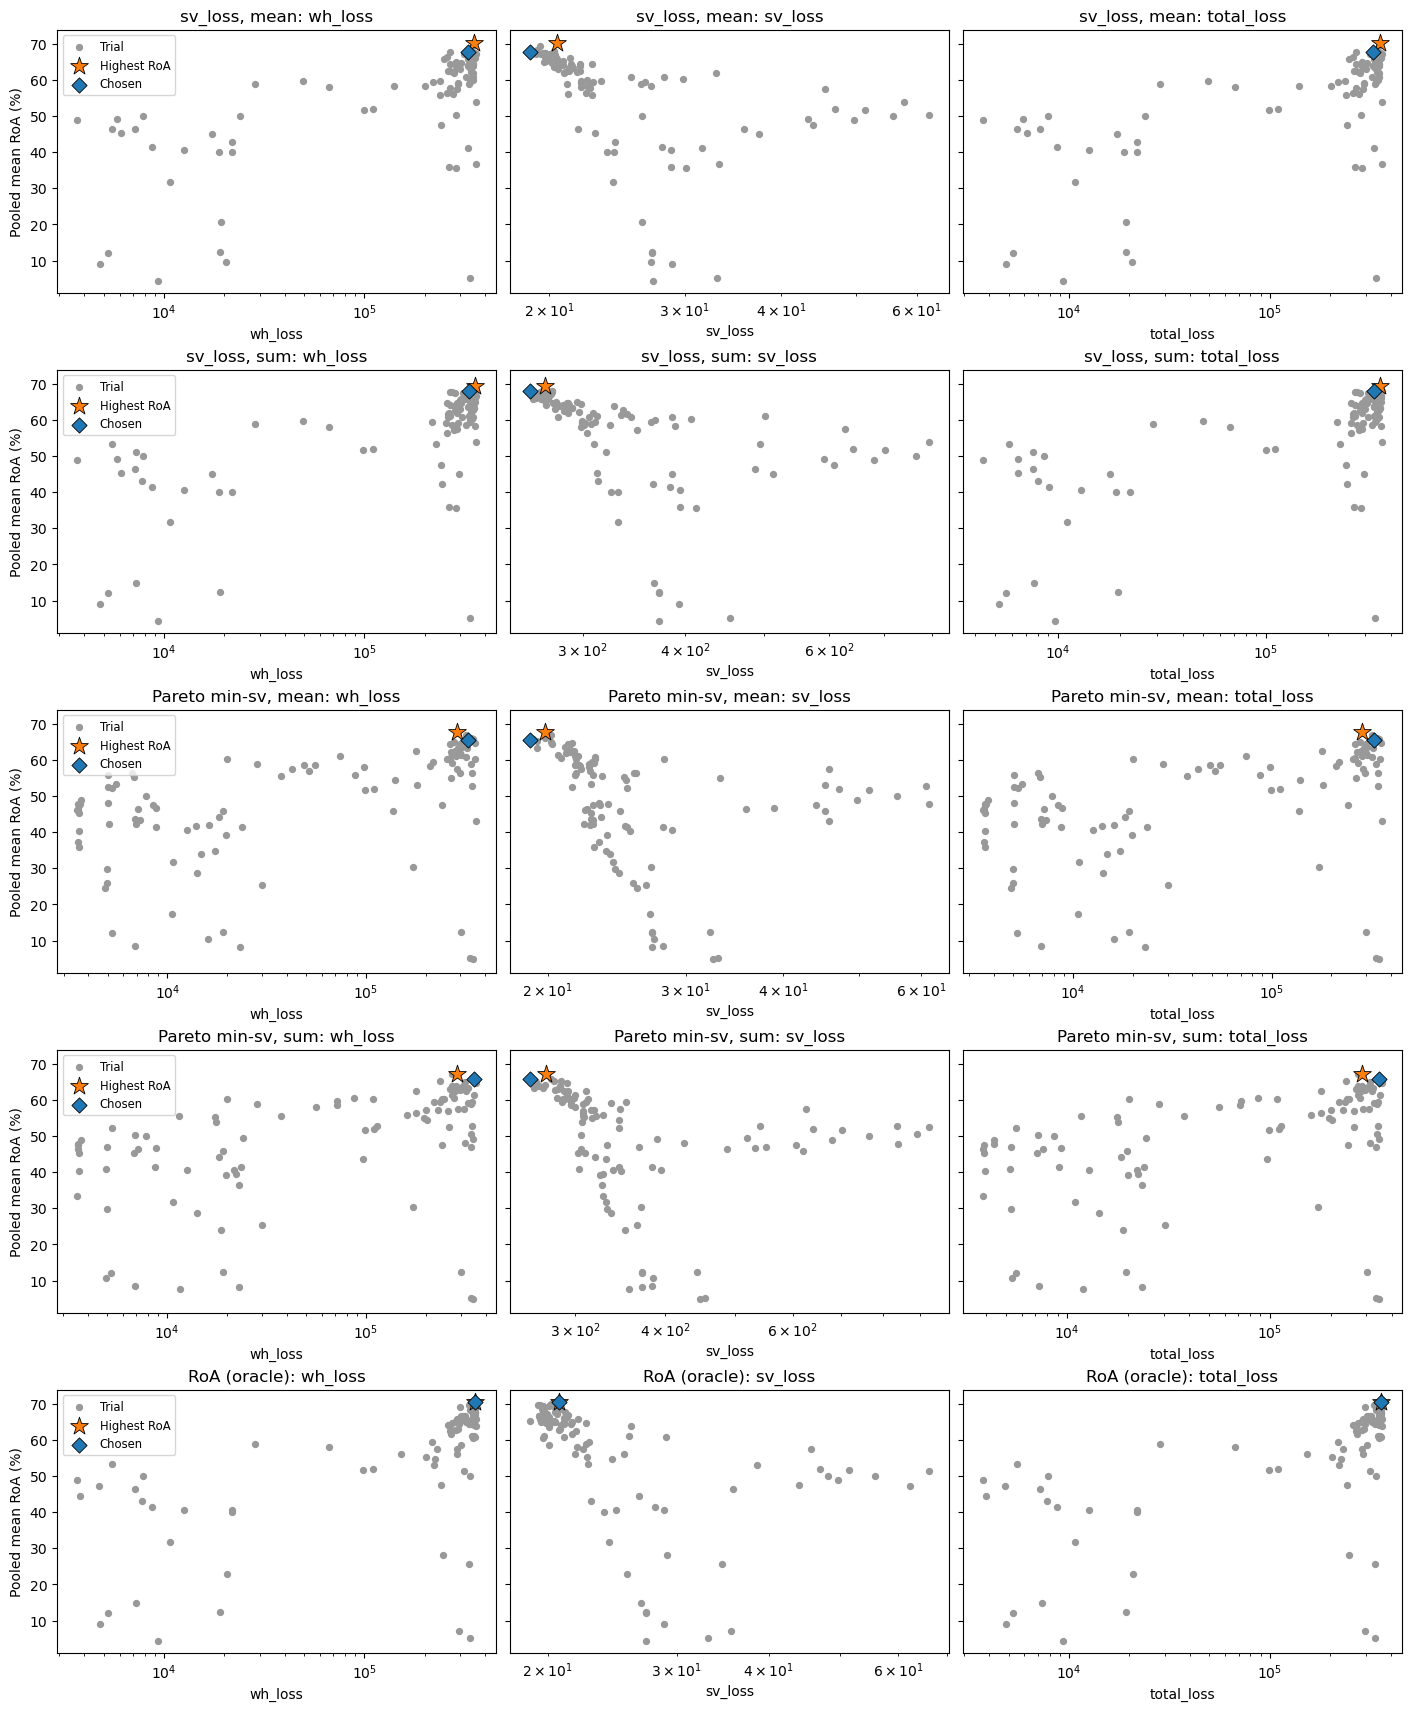

In [6]:
names = list(cfg["searches"])
fig, axs = plt.subplots(
    len(names), 3, figsize=(14, 3.4 * len(names)), layout="constrained", sharey=True, squeeze=False
)
for row, name in zip(axs, names):
    search = report.complete_trials(trials, name)
    plot_search_landscape(
        search, int(search.loc[search["chosen"], "number"].iloc[0]), title=labels[name], axs=row
    )
plt.show()

### Pareto fronts

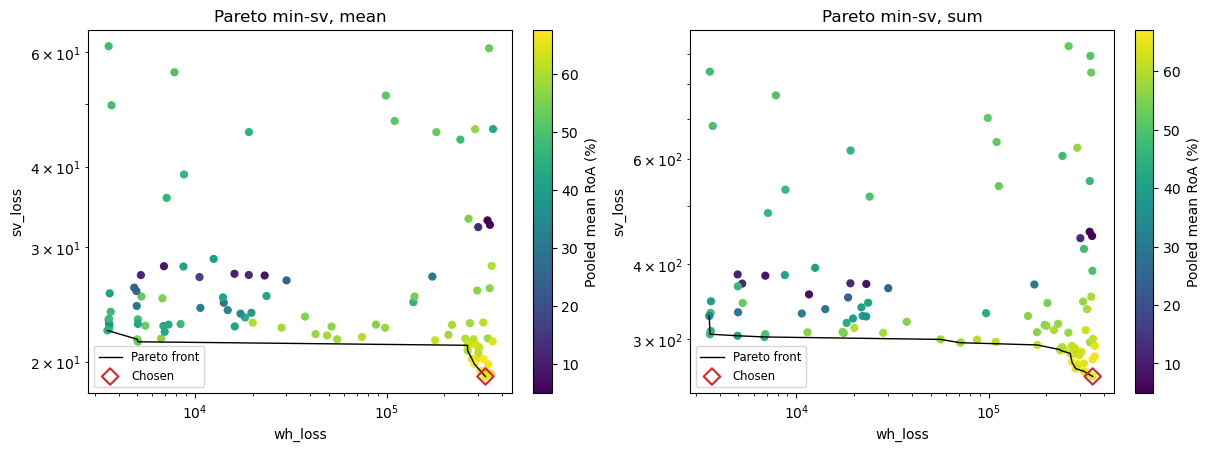

In [7]:
pareto = [n for n in names if len(cfg["searches"][n]["objectives"]) > 1]
fig, axs = plt.subplots(
    1, len(pareto), figsize=(6 * len(pareto), 4.4), layout="constrained", squeeze=False
)
for ax, name in zip(axs[0], pareto):
    search = report.complete_trials(trials, name)
    chosen_trial = int(search.loc[search["chosen"], "number"].iloc[0])
    plot_search_front(search, report.front_numbers(search), chosen_trial, title=labels[name], ax=ax)
plt.show()

### Convergence

The best objective value reached so far at each trial (for a Pareto search, its `sv_loss`,
which the min-sv selection uses).

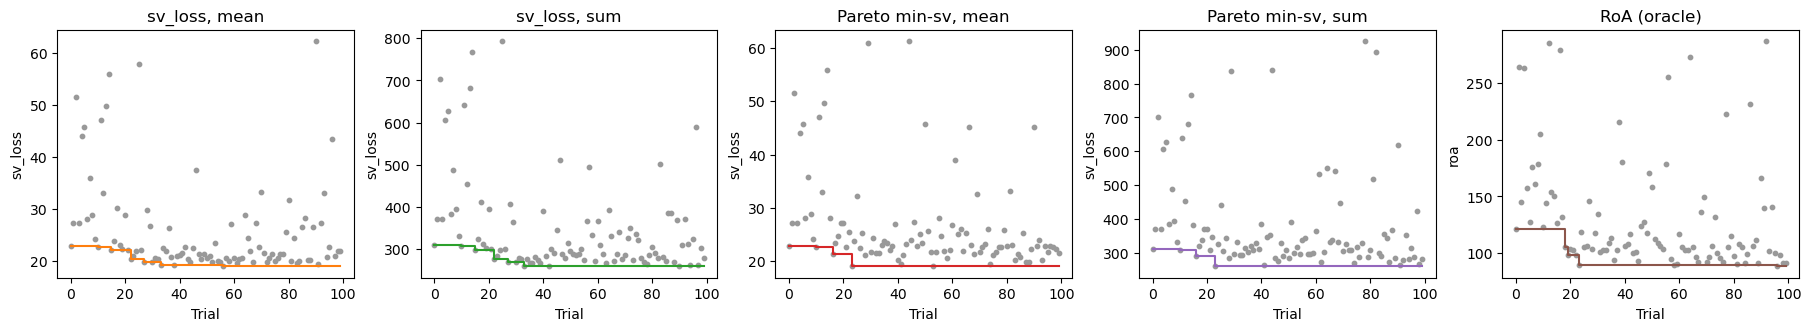

In [8]:
palette = dict(zip(labels.values(), sns.color_palette("tab10", len(labels))))
fig, axs = plt.subplots(
    1, len(names), figsize=(3.6 * len(names), 3.2), layout="constrained", squeeze=False
)
for ax, name in zip(axs[0], names):
    search = report.complete_trials(trials, name)
    columns = report.objective_columns(search)
    column = "values_sv_loss" if "values_sv_loss" in columns else columns[0]
    curve = report.best_so_far(search, column)
    ax.scatter(curve["number"], curve["value"], s=10, color="0.6")
    ax.step(curve["number"], curve["best_so_far"], where="post", color=palette[labels[name]])
    ax.set(title=labels[name], xlabel="Trial", ylabel=column.split("_", 1)[1])
plt.show()

### Hyperparameter scales

Pooled RoA of every trial of every search against each parameter: how sensitive tracking is to
each one, whichever objective chose it. The searches share a seed, so their random start-up
trials are the same parameter sets and overlap here.

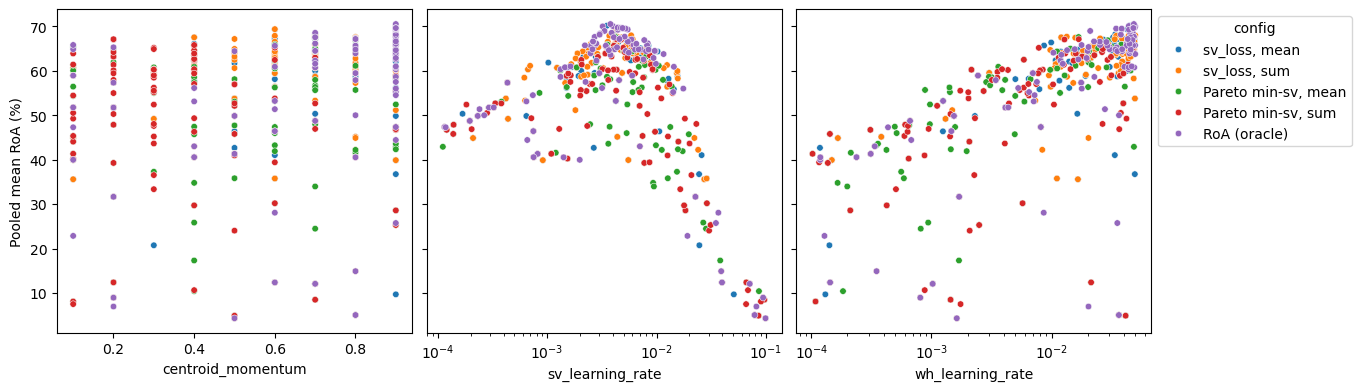

In [9]:
plot_search_parameters(report.complete_trials(trials), hue="config")
plt.show()

Next: [3. Apply](3_apply.ipynb) each search's winner to every recording.